<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E7%8E%B0%E4%BB%A3%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E7%9A%84%E5%90%AF%E5%8F%91%E5%BC%8F%E6%A6%82%E5%BF%B5/HeuristicConcepts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

梳理一些用于设计深层神经网络的启发式概念，包括VGG、NiN、
和GoogLeNet。
##使用块的网络VGG
###VGG块
```
经典卷积神经网络的基本组成部分是下面的这个序列：

- 带填充以保持分辨率的卷积层；

- 非线性激活函数，如ReLU；

- 池化层。

```
而一个VGG块与之类似，由一系列卷积层组成，后面再加上用于空间下采样的最大池化层。在下面的代码中，我们定义了一个名为vgg_block的函数来实现一个VGG块。


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

该函数有三个参数，分别对应于卷积层的数量`num_convs`、输入通道的数量`in_channels`
和输出通道的数量`out_channels`.

###VGG网络
VGG网络可以分为两部分：第一部分主要由卷积层和汇聚层组成，第二部分由全连接层组成。
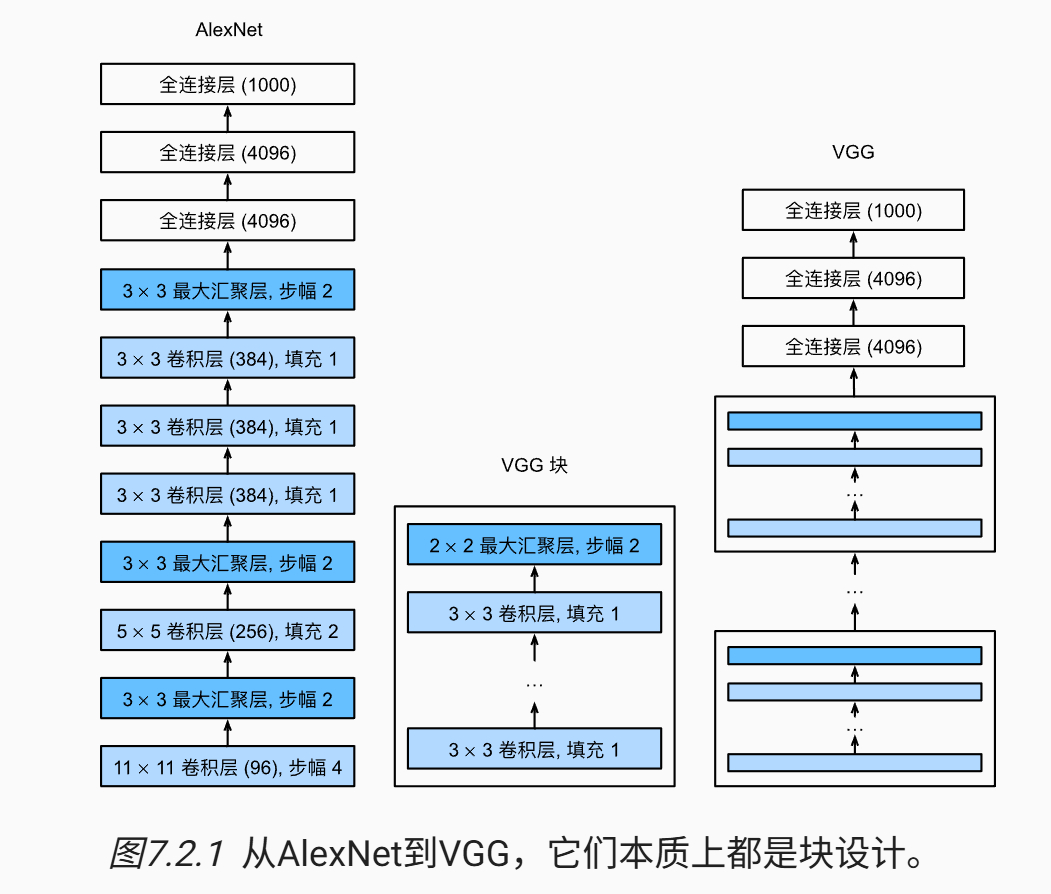

原始VGG网络有5个卷积块，其中前两个块各有一个卷积层，后三个块各包含两个卷积层。 第一个模块有64个输出通道，每个后续模块将输出通道数量翻倍，直到该数字达到512。由于该网络使用8个卷积层和3个全连接层，因此它通常被称为VGG-11。

下面的代码实现了VGG-11。可以通过在`conv_arch`上执行for循环来简单实现。

In [3]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全连接层部分
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10))

net = vgg(conv_arch)

接下来，我们将构建一个高度和宽度为224的单通道数据样本，以[**观察每个层输出的形状**]。

In [4]:
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__,'output shape:\t',X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


In [5]:
def load_data_fashion_mnist(batch_size, resize=224):
    """
    下载Fashion-MNIST并创建训练集和测试集的数据加载器。
    """
    transform = transforms.Compose([
        transforms.Resize((resize, resize)),
        transforms.ToTensor()
    ])

    train_dataset = datasets.FashionMNIST(
        root="../data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.FashionMNIST(
        root="../data",
        train=False,
        transform=transform,
        download=True
    )

    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_iter, test_iter


def try_gpu():
    """有GPU就使用GPU，否则使用CPU。"""
    if torch.cuda.is_available():
        return torch.device("cuda:0")

    return torch.device("cpu")


def accuracy(y_hat, y):
    """计算一个批次中预测正确的样本数量。"""
    predicted = y_hat.argmax(dim=1)
    correct = (predicted == y).sum()

    return correct.item()


def evaluate_accuracy_gpu(net, data_iter, device):
    """在测试集上计算分类准确率。"""
    net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)

            y_hat = net(X)

            correct += accuracy(y_hat, y)
            total += y.numel()

    return correct / total


def init_weights(module):
    """
    使用Xavier均匀初始化。
    """
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):


    # 在训练前重新初始化卷积层和全连接层的权重
    net.apply(init_weights)

    print(f"training on {device}")

    net.to(device)


    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_function = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for X, y in train_iter:
            X = X.to(device)
            y = y.to(device)

            # 清除上一轮反向传播得到的梯度
            optimizer.zero_grad()

            # 前向传播
            y_hat = net(X)

            # 计算损失
            loss = loss_function(y_hat, y)

            # 反向传播
            loss.backward()

            # 更新参数
            optimizer.step()

            batch_size = y.size(0)

            total_loss += loss.item() * batch_size
            total_correct += accuracy(y_hat, y)
            total_samples += batch_size

        train_loss = total_loss / total_samples
        train_accuracy = total_correct / total_samples

        test_accuracy = evaluate_accuracy_gpu(
            net,
            test_iter,
            device
        )

        print(
            f"epoch {epoch + 1:2d}, "
            f"loss {train_loss:.4f}, "
            f"train acc {train_accuracy:.4f}, "
            f"test acc {test_accuracy:.4f}"
        )


def main():
    # 将每层通道数缩小到原来的1/4，降低计算量
    ratio = 4

    small_conv_arch = [
        (num_convs, out_channels // ratio)
        for num_convs, out_channels in conv_arch
    ]

    # 实际用于训练的是缩小后的VGG网络
    net = vgg(small_conv_arch)

    # 训练超参数
    lr = 0.05
    num_epochs = 10
    batch_size = 128

    train_iter, test_iter = load_data_fashion_mnist(
        batch_size=batch_size,
        resize=224
    )

    device = try_gpu()

    train_ch6(
        net,
        train_iter,
        test_iter,
        num_epochs,
        lr,
        device
    )


if __name__ == "__main__":
    main()

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.1MB/s]


training on cuda:0
epoch  1, loss 0.8786, train acc 0.6807, test acc 0.8472
epoch  2, loss 0.3918, train acc 0.8561, test acc 0.8683
epoch  3, loss 0.3214, train acc 0.8822, test acc 0.8853
epoch  4, loss 0.2814, train acc 0.8967, test acc 0.8963
epoch  5, loss 0.2563, train acc 0.9059, test acc 0.9064
epoch  6, loss 0.2313, train acc 0.9158, test acc 0.9061
epoch  7, loss 0.2151, train acc 0.9207, test acc 0.9067
epoch  8, loss 0.2003, train acc 0.9266, test acc 0.9205
epoch  9, loss 0.1861, train acc 0.9310, test acc 0.9183
epoch 10, loss 0.1739, train acc 0.9367, test acc 0.9184


VGG 没有提出特殊的优化器或复杂的训练算法，但提出了一种非常重要的网络架构设计原则：使用统一的小卷积核和重复卷积块，有规律地增加网络深度。加深深度，使用更多次的非线性激活，让网络可以学习更复杂的特性。

##网络中的网络NiN
LeNet、AlexNet和VGG都有一个共同的设计模式：通过一系列的卷积层与汇聚层来提取空间结构特征；然后通过全连接层对特征的表征进行处理。 AlexNet和VGG对LeNet的改进主要在于如何扩大和加深网络。 或者，我们想象在这个过程的早期使用全连接层，然而这样可能会完全放弃表征的空间结构。 网络中的网络（NiN）提供了一个非常简单的解决方案：在每个像素的通道上分别使用多层感知机